In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Evaluation modules
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)
from sklearn.model_selection import RandomizedSearchCV

# Classifiers (CatBoost removed)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Load data
data_dict = joblib.load('processed_churn_data.pkl')
X_train = data_dict['X_train']
X_test = data_dict['X_test']
y_train = data_dict['y_train']
y_test = data_dict['y_test']

print("Dataset loaded successfully!")
print(f"Training shape: {X_train.shape}, Test shape: {X_test.shape}")


Dataset loaded successfully!
Training shape: (8278, 36), Test shape: (1409, 36)


In [3]:
# Initialize models (CatBoost removed)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=6),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

# Train models
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

print("All models trained successfully!")


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
All models trained successfully!


In [4]:
# Function to evaluate performance metrics
def get_metrics(model, X, y_true):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_prob)
    }

# Gather metrics
results = {}
for name, model in trained_models.items():
    results[name] = get_metrics(model, X_test, y_test)

# Compare models in tabular form
df_results = pd.DataFrame(results).T
df_results.sort_values(by='Recall', ascending=False)


,Accuracy,Precision,Recall,F1,ROC AUC
Decision Tree,0.696238,0.457143,0.770053,0.573705,0.807881
Random Forest,0.760114,0.533457,0.767380,0.629386,0.839714
Logistic Regression,0.764372,0.541502,0.732620,0.622727,0.839484
LightGBM,0.769340,0.552017,0.695187,0.615385,0.826844
XGBoost,0.766501,0.549451,0.668449,0.603136,0.815529


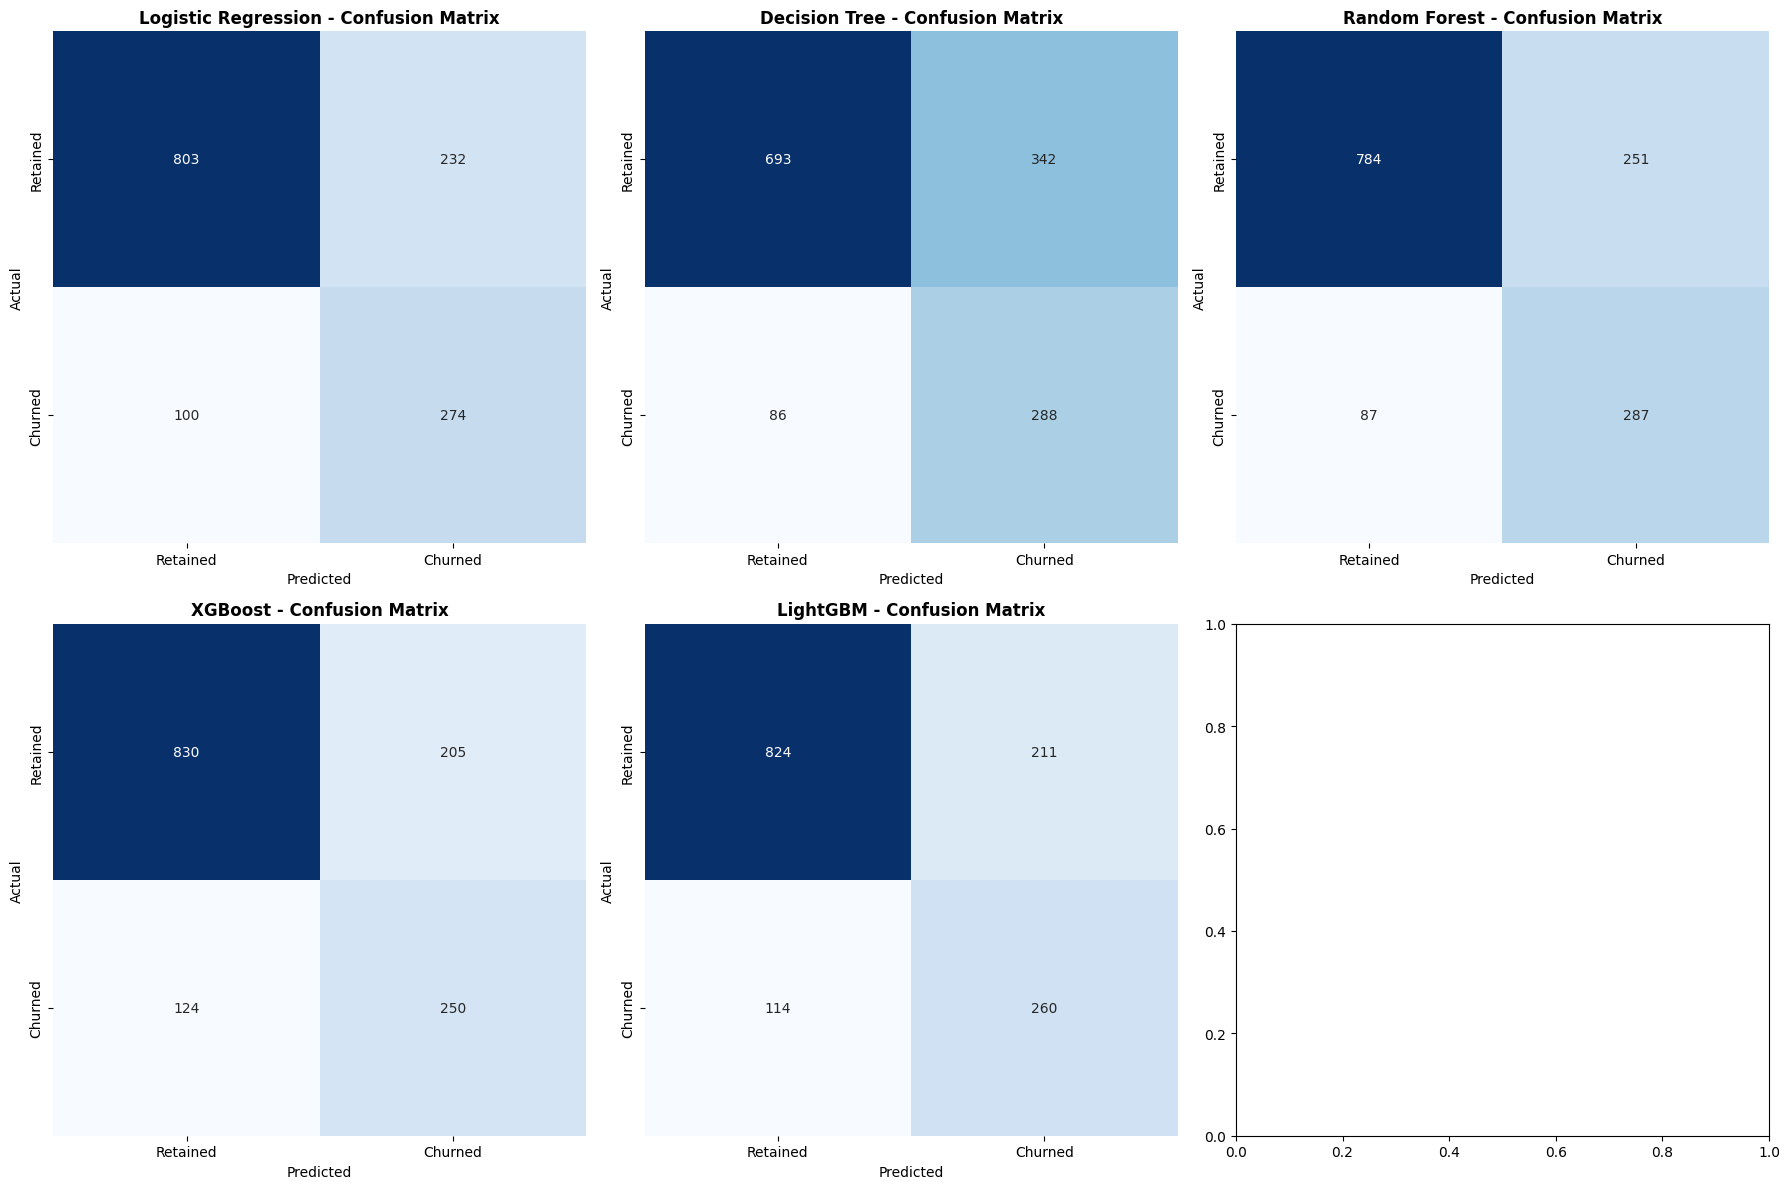

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
    axes[idx].set_title(f'{name} - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()


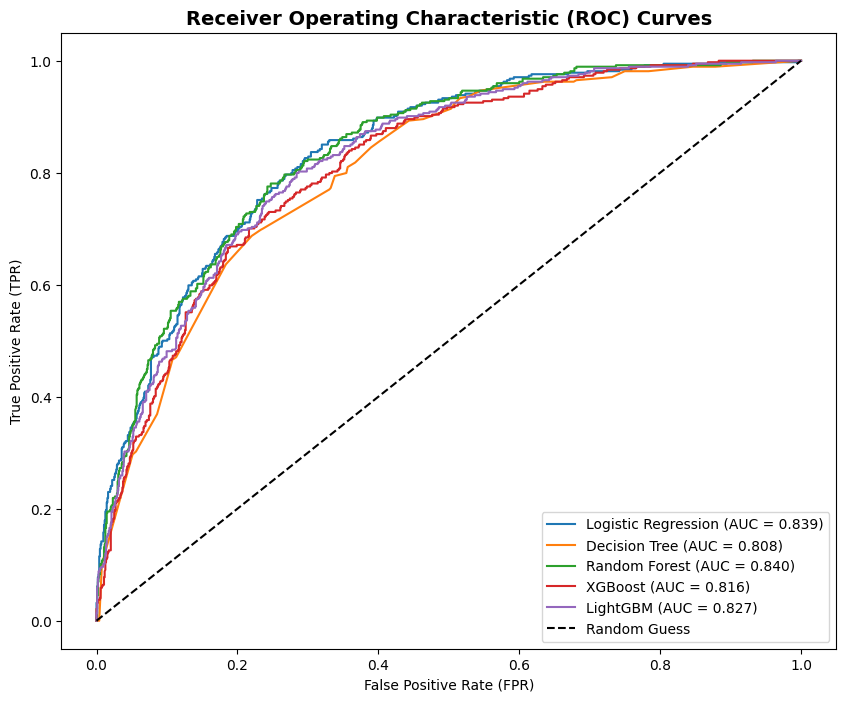

In [6]:
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.show()


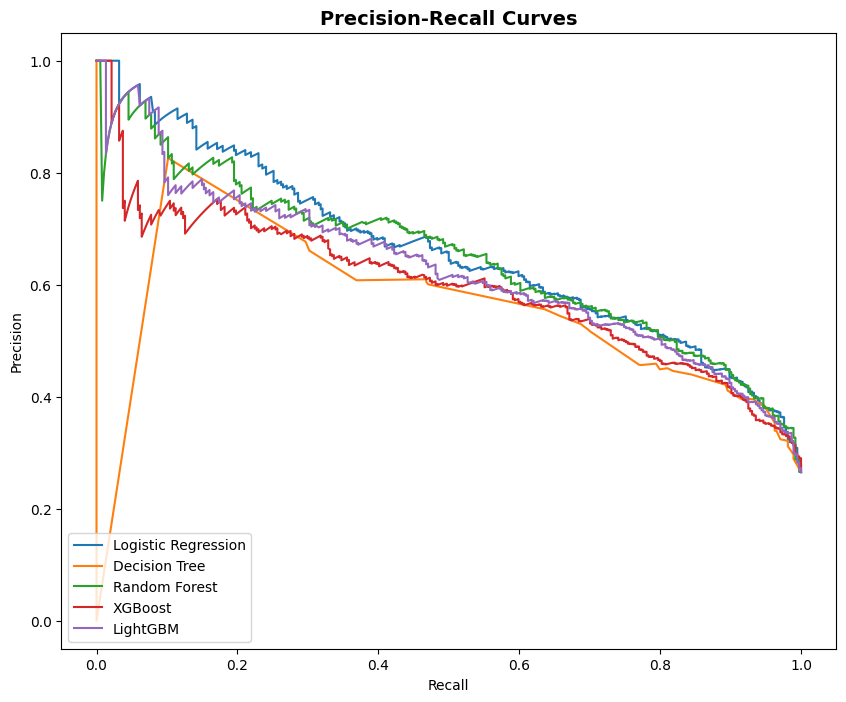

In [7]:
plt.figure(figsize=(10, 8))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=f'{name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.show()


C:\Users\swastik\AppData\Local\Temp\ipykernel_21904\276462698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


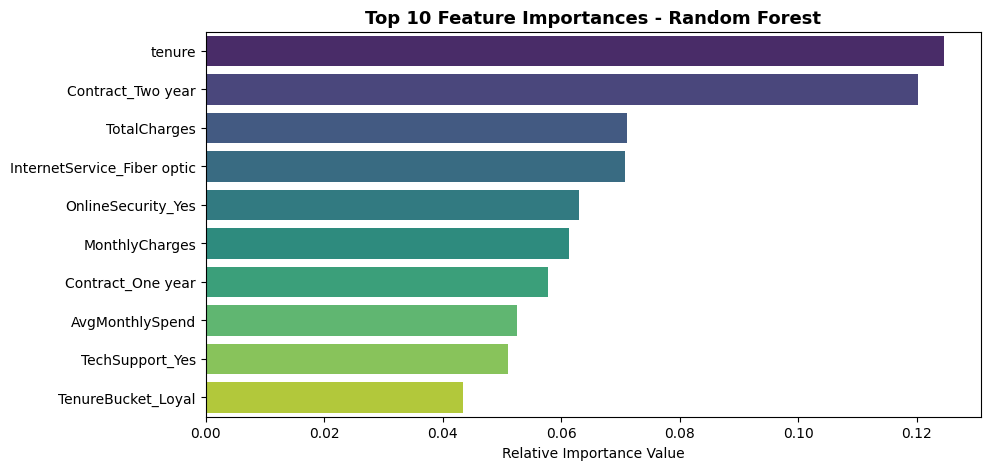

C:\Users\swastik\AppData\Local\Temp\ipykernel_21904\276462698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


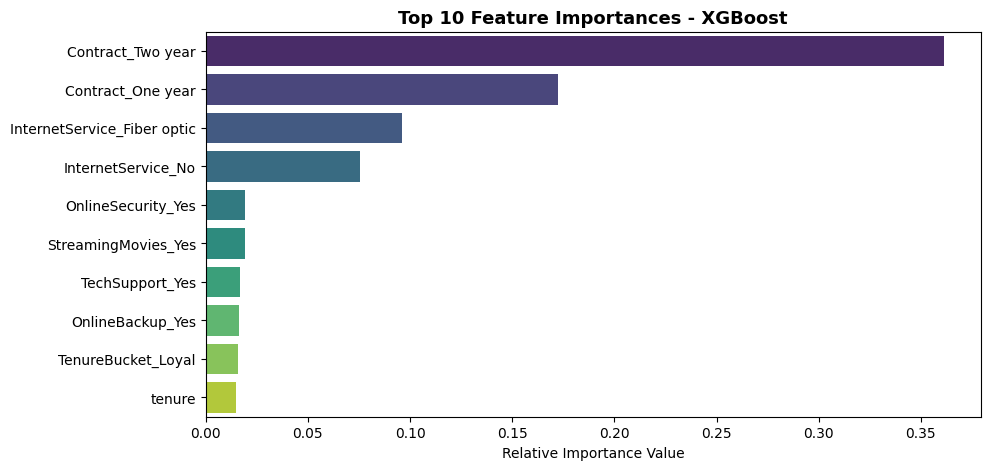

C:\Users\swastik\AppData\Local\Temp\ipykernel_21904\276462698.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')


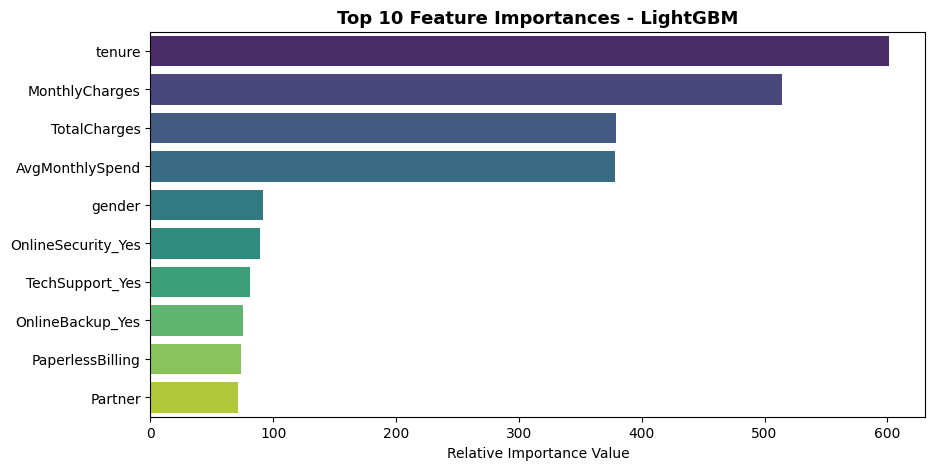

In [8]:
# Extract feature importance from tree-based estimators
tree_models = {
    'Random Forest': trained_models['Random Forest'],
    'XGBoost': trained_models['XGBoost'],
    'LightGBM': trained_models['LightGBM']
}

feature_names = X_train.columns

for name, model in tree_models.items():
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]  # Get top 10 features
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette='viridis')
    plt.title(f'Top 10 Feature Importances - {name}', fontsize=13, fontweight='bold')
    plt.xlabel('Relative Importance Value')
    plt.show()


In [9]:
# XGBoost tuning parameters grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# Prioritize Recall when evaluating
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=15,
    scoring='recall',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Tuning hyperparameters on XGBoost (targeting Recall)...")
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print(f"\nBest Parameters found:\n{random_search.best_params_}")


Tuning hyperparameters on XGBoost (targeting Recall)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\swastik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 45.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\swastik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\swastik\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py", line 729, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\swastik\AppData\Local\Programs\Python\Python311\Lib\site-


Best Parameters found:
{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [10]:
# Compare optimized XGBoost with baseline XGBoost
base_metrics = results['XGBoost']
opt_metrics = get_metrics(best_xgb, X_test, y_test)

comparison_df = pd.DataFrame({
    'Baseline XGBoost': base_metrics,
    'Optimized XGBoost': opt_metrics
})

print("Performance comparison after Hyperparameter Tuning:")
print(comparison_df.round(4))

# Detailed Classification Report
y_pred_opt = best_xgb.predict(X_test)
print("\n--- Optimized XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_opt))


Performance comparison after Hyperparameter Tuning:
           Baseline XGBoost  Optimized XGBoost
Accuracy             0.7665             0.7559
Precision            0.5495             0.5284
Recall               0.6684             0.7460
F1                   0.6031             0.6186
ROC AUC              0.8155             0.8299

--- Optimized XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [11]:
# Select optimized XGBoost as final deployment model
final_model = best_xgb

# Save model artifacts
model_payload = {
    'model': final_model,
    'scaler': data_dict['scaler'],
    'feature_names': data_dict['features']
}

joblib.dump(model_payload, 'final_churn_xgb_model.pkl')
print("Best model package saved to 'final_churn_xgb_model.pkl'!")


Best model package saved to 'final_churn_xgb_model.pkl'!
